# Lab: Fooling AI with Adversarial Inputs (FGSM)

In this lab, we will perform a **Fast Gradient Sign Method (FGSM)** attack. We will take a correctly classified digit from the MNIST dataset and add "mathematically calculated noise" to it. This noise is designed to maximize the model's error while remaining nearly invisible to the human eye.

---

## 1. Setup and Data Preparation

First, we'll import our libraries and load the MNIST dataset. Since we are in Colab, these are already installed.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# Set device (CPU is perfectly fine for this!)
device = torch.device("cpu")

# Load MNIST test set
test_loader = torch.utils.data.DataLoader(
    datasets.MNIST('../data', train=False, download=True,
                   transform=transforms.Compose([transforms.ToTensor(),])),
    batch_size=1, shuffle=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 44.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.17MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 8.82MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.31MB/s]


---

## 2. The Target Model

We need a model to attack. For a quick demo, we'll define a simple CNN and train it for **one epoch**. This may take 5 - 6 minutes.

In [ ]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.dropout1 = nn.Dropout(0.25)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)
        x = self.dropout1(x)
        x = torch.flatten(x, 1)
        x = self.fc2(self.fc1(x))
        return F.log_softmax(x, dim=1)

# Initialize and train briefly
model = Net().to(device)
optimizer = optim.Adadelta(model.parameters(), lr=1.0)
print("Training model for 1 epoch...")
model.train()
for data, target in test_loader: # Using test_loader just for a quick subset training
    optimizer.zero_grad()
    output = model(data)
    loss = F.nll_loss(output, target)
    loss.backward()
    optimizer.step()
model.eval()
print("Model ready!")

Training model for 1 epoch...
Model ready!


---

## 3. The FGSM Attack Function

This is the core of the lab. The attack follows this formula:

$$x_{adv} = x + \epsilon \cdot \text{sign}(\nabla_x J(\theta, x, y))$$

> **Note:** We aren't changing the model weights ($\theta$). We are calculating the gradient of the loss with respect to the **image pixels** ($x$).

In [ ]:
def fgsm_attack(image, epsilon, data_grad):
    # Collect the elements-wise sign of the data gradient
    sign_data_grad = data_grad.sign()

    # Create the adversarial image by adjusting each pixel
    perturbed_image = image + epsilon * sign_data_grad

    # Adding noise might push pixels out of [0,1] range, so we clip them
    perturbed_image = torch.clamp(perturbed_image, 0, 1)

    return perturbed_image

---

## 4. Execution: Breaking the Model

We will grab one image, ensure the model predicts it correctly, and then attack it.

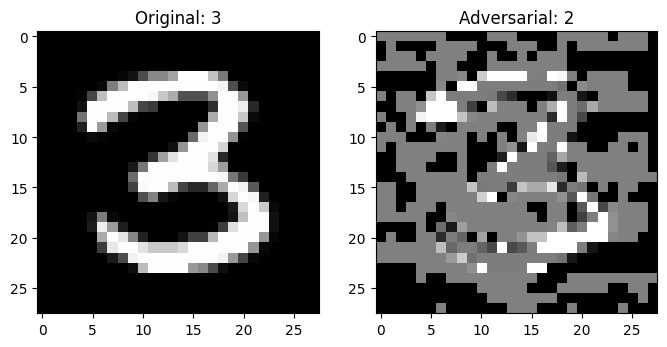

Epsilon: 0.5
True Label: 3
Model Prediction: 2


In [ ]:
# 1. Get a test image
image, target = next(iter(test_loader))
image.requires_grad = True # CRITICAL: We need gradients for the input image

# 2. Forward pass
output = model(image)
init_pred = output.max(1, keepdim=True)[1]

# 3. If the model was wrong to begin with, skip (don't attack a broken model)
if init_pred.item() != target.item():
    print("Initial prediction was wrong. Run this cell again for a new image.")
else:
    # 4. Calculate Loss and Backpropagate to the IMAGE
    loss = F.nll_loss(output, target)
    model.zero_grad()
    loss.backward()

    # 5. Create Adversarial Image (start from epsilon 0.15, then try different eps values)
    eps = 0.5
    perturbed_data = fgsm_attack(image, eps, image.grad.data)

    # 6. Re-classify the "noisy" image
    output_adv = model(perturbed_data)
    final_pred = output_adv.max(1, keepdim=True)[1]

    # --- VISUALIZATION ---
    plt.figure(figsize=(8,4))
    plt.subplot(1, 2, 1)
    plt.title(f"Original: {init_pred.item()}")
    plt.imshow(image.detach().numpy().squeeze(), cmap="gray")

    plt.subplot(1, 2, 2)
    plt.title(f"Adversarial: {final_pred.item()}")
    plt.imshow(perturbed_data.detach().numpy().squeeze(), cmap="gray")
    plt.show()

    print(f"Epsilon: {eps}")
    print(f"True Label: {target.item()}")
    print(f"Model Prediction: {final_pred.item()}")

---

## 5. Questions

1. **The Visual Test:** Does the adversarial image look like the "True Label" or the "Model Prediction" to you?
2. **The Epsilon Trade-off:** If you change `eps` to `0.01`, does the attack still work? What if you change it to `0.5`? (Try it in the code above!)
3. **The Defense:** How would you stop this? (Hint: What if we included adversarial images in the *training* set?)

---

## Step 6: PGD: the iterative approach

In this step, we move from a one-shot attack to an iterative one. PGD works by repeating the FGSM logic multiple times with a smaller step size ($\alpha$) and "projecting" the result back to ensure we don't drift too far from the original image.

### 1. The PGD Formula

Unlike FGSM, we update the image over $t$ iterations:

$$x_{t+1} = \text{Clip}_{x, \epsilon} \{ x_t + \alpha \cdot \text{sign}(\nabla_{x_t} J(\theta, x_t, y)) \}$$

* **$\alpha$**: The step size for each iteration.
* **$\text{Clip}_{x, \epsilon}$**: This ensures the adversarial image stays within a distance of $\epsilon$ from the original $x$.

### 2. The PGD Attack Function

Notice the `for` loop that makes it iterative.

In [ ]:
def pgd_attack_random(model, image, target, epsilon, alpha, iterations, random_start=True):
    image = image.to(device)
    target = target.to(device)

    # 1. Initialize the perturbation
    if random_start:
        # Start at a random point within the epsilon ball
        delta = torch.empty_like(image).uniform_(-epsilon, epsilon)
    else:
        # Start exactly at the original image
        delta = torch.zeros_like(image)

    # Constrain initial delta to be within epsilon and valid pixel range
    delta = torch.clamp(delta, -epsilon, epsilon)
    perturbed_image = torch.clamp(image + delta, 0, 1).detach()

    for i in range(iterations):
        perturbed_image.requires_grad = True
        output = model(perturbed_image)

        loss = F.nll_loss(output, target)
        model.zero_grad()
        loss.backward()

        with torch.no_grad():
            # Standard FGSM step
            adv_image = perturbed_image + alpha * perturbed_image.grad.sign()

            # PROJECT: 1. Keep within epsilon ball of ORIGINAL image
            eta = torch.clamp(adv_image - image, min=-epsilon, max=epsilon)
            # PROJECT: 2. Keep within valid [0,1] pixel range
            perturbed_image = torch.clamp(image + eta, min=0, max=1)

        perturbed_image = perturbed_image.detach()

    return perturbed_image

### 3. Execution: Comparing FGSM vs. PGD

Run this cell to see how PGD performs compared to the one-shot FGSM.

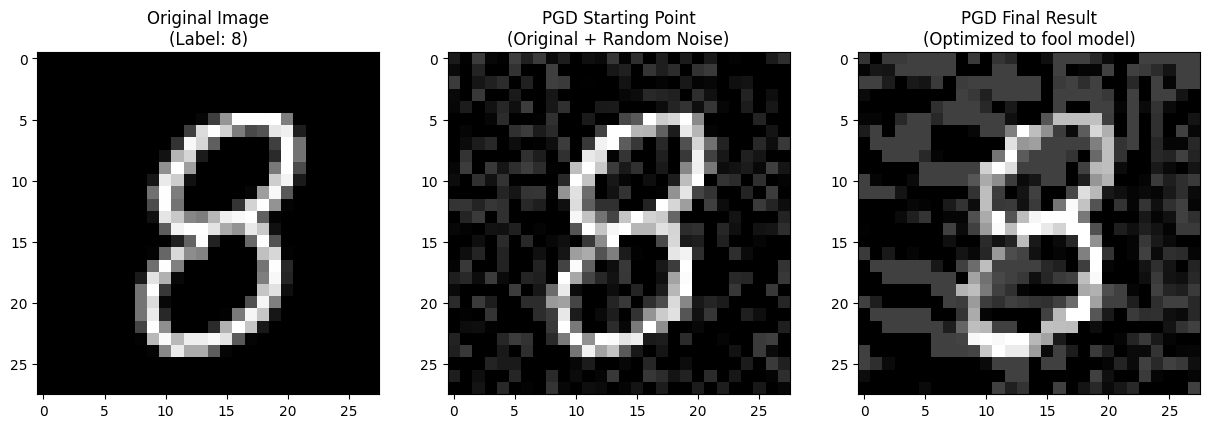

Original Prediction: 8
Adversarial Prediction: 3


In [ ]:
# Attack Parameters
epsilon = 0.25
alpha = 0.02
iterations = 40

# Get a fresh image
image, target = next(iter(test_loader))

# --- GENERATE THREE STAGES ---
# 1. Just the Random Noise (The starting point of the attack)
with torch.no_grad():
    random_noise = torch.empty_like(image).uniform_(-epsilon, epsilon)
    start_point = torch.clamp(image + random_noise, 0, 1)

# 2. The Final PGD Attack Result
final_adv = pgd_attack_random(model, image, target, epsilon, alpha, iterations, random_start=True)

# --- VISUALIZATION ---
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title(f"Original Image\n(Label: {target.item()})")
plt.imshow(image.squeeze(), cmap="gray")

plt.subplot(1, 3, 2)
plt.title(f"PGD Starting Point\n(Original + Random Noise)")
plt.imshow(start_point.squeeze(), cmap="gray")

plt.subplot(1, 3, 3)
plt.title(f"PGD Final Result\n(Optimized to fool model)")
plt.imshow(final_adv.squeeze(), cmap="gray")

plt.show()

# Final Check
model.eval()
with torch.no_grad():
    orig_pred = model(image).argmax(dim=1).item()
    adv_pred = model(final_adv).argmax(dim=1).item()
    print(f"Original Prediction: {orig_pred}")
    print(f"Adversarial Prediction: {adv_pred}")



---

## Step 7: The Carlini & Wagner (L2) Attack

While FGSM and PGD try to maximize the loss within a fixed budget ($\epsilon$), the CW attack flips the script: it tries to find the **minimum possible perturbation** required to change the classification. It is widely considered one of the most powerful white-box attacks because it can bypass many defenses (like defensive distillation) that stop FGSM/PGD.

The CW attack is an optimization problem. We want to find a perturbation $\delta$ that minimizes:


$$\|\delta\|_2^2 + c \cdot f(x + \delta)$$

Where:

* $\|\delta\|_2^2$ is the **L2 distance** (keeping the change invisible).
* $f(x)$ is an **objective function** that is only solved when the model is fooled.
* $c$ is a constant that balances "stealth" vs "success."

### 1. The CW Attack Logic

We will use a simplified version of the $L_2$ attack. Instead of the complex $tanh$ transformation used in the original paper (which can be finicky for a 5-minute demo), we will optimize the pixels directly with a "hinge loss" on the logits.

In [ ]:
def cw_l2_attack(model, image, target, confidence=0, c=1, lr=0.01, iterations=100):
    image = image.to(device)
    target = target.to(device)

    # We optimize the 'perturbation' (delta)
    delta = torch.zeros_like(image, requires_grad=True)
    optimizer = optim.Adam([delta], lr=lr)

    for i in range(iterations):
        # Apply perturbation and ensure it's a valid image [0,1]
        adv_image = torch.clamp(image + delta, 0, 1)

        # Get logits (the raw scores before Softmax)
        outputs = model(adv_image)

        # Calculate f(x) - the objective function
        # We want the score of the 'correct' class to be lower than
        # the score of the 'next best' class.
        target_logit = outputs[0][target]

        # Get the maximum logit that isn't the target
        other_logits = torch.cat((outputs[0][:target], outputs[0][target+1:]))
        max_other_logit = torch.max(other_logits)

        # f(x) = max(target_logit - max_other_logit, -confidence)
        # If this is negative, the model is successfully fooled.
        loss_f = torch.clamp(target_logit - max_other_logit + confidence, min=0)

        # Total Loss = L2 distance + c * f(x)
        l2_dist = torch.norm(delta, p=2)
        loss = l2_dist + c * loss_f

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    return torch.clamp(image + delta, 0, 1).detach()

### 2. Execution: The "Surgical" Bypass

Run this to see how CW compares to your previous attacks.

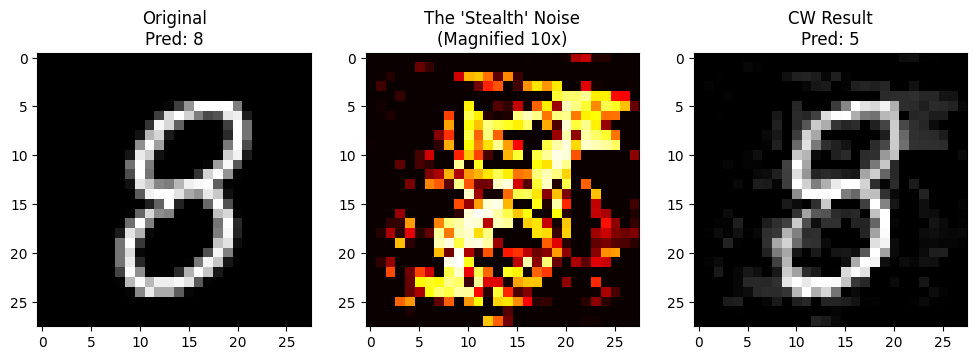

L2 Distortion: 2.3543


In [ ]:
# Attack Parameters
# c=10 gives the attack more 'power' to fool the model at the cost of visibility
cw_image = cw_l2_attack(model, image, target, c=10, iterations=100)

# --- VISUALIZATION ---
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title(f"Original\nPred: {target.item()}")
plt.imshow(image.squeeze(), cmap="gray")

# Calculate the difference (what the attack actually added)
diff = (cw_image - image).abs()

plt.subplot(1, 3, 2)
plt.title("The 'Stealth' Noise\n(Magnified 10x)")
plt.imshow(diff.squeeze() * 10, cmap="hot")

plt.subplot(1, 3, 3)
plt.title(f"CW Result\nPred: {model(cw_image).argmax().item()}")
plt.imshow(cw_image.squeeze(), cmap="gray")

plt.show()

print(f"L2 Distortion: {torch.norm(cw_image - image, p=2).item():.4f}")

---

## Notes

1. **The "Stealth" Noise:** CW doesn't just add random static like FGSM. It targets specific **edges and features** that are critical to the model's decision-making.
2. **L2 vs Linf:** Explain that while PGD cares about the *maximum* change to any one pixel ($L_\infty$), CW cares about the *total* change ($L_2$). This makes CW noise look much more like "natural blur" than "digital static."
3. **Optimization as a Tool:** This demo shifts the student's perspective from "using a formula" to "running an optimization loop" against an AI.
---
* **Speed:** CW is slower than PGD. 100 iterations on a CPU in Colab will take about 2–4 seconds per image.
* **Failure:** If the attack fails to change the label, increase `c` (the weight of the goal) or `iterations`. If the noise is too obvious, decrease `c`.